# Activation functions and why they matter

### The one line that stops a deep network collapsing into a shallow one

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Why a network without a non-linearity is a linear model wearing a costume, what the six common activations do to a signal and to a gradient, how to measure a vanishing gradient instead of taking my word for it, how ReLU units die and what stops them, and which activation to reach for first |
| **You should already know** | [The same network in PyTorch](../03-the-same-net-in-pytorch/) |
| **Dataset** | UCI Dry Bean (13,611 × 16, 7 classes) |
| **Runtime** | Two to three minutes on a laptop CPU |
| **Next** | [07-05 Optimisers](../05-optimisers/) |

---

## 1. Why a non-linearity is required at all

Stack two linear layers and write out what they compute:

$$W_2(W_1x + b_1) + b_2 = (W_2W_1)x + (W_2b_1 + b_2) = Wx + b$$

The product $W_2W_1$ is a matrix, and $W_2b_1 + b_2$ is a vector. Two layers
are one layer. The argument repeats for any depth, so a hundred linear layers
are still one linear layer with a very slow forward pass.

That is the whole reason activations exist. Everything else in this notebook is
about which non-linearity to pick and what each one costs you.

I would rather measure this than assert it, so section 1 trains a deep stack
with `nn.Identity` between the layers, collapses its weights into a single
matrix by hand, and checks that the collapsed matrix reproduces the network's
outputs.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__}, running on {device}")

torch 2.11.0+cu128, running on cuda


The same Dry Bean setup as the [PyTorch notebook](../03-the-same-net-in-pytorch/):
sixteen geometric measurements of a grain, seven varieties, standardised so no
feature dominates by unit alone.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

X_bean, y_bean = datasets.dry_bean()
encoder = LabelEncoder().fit(y_bean)

X_train, X_test, y_train, y_test = train_test_split(
    X_bean.values, encoder.transform(y_bean), test_size=0.25,
    stratify=y_bean, random_state=SEED)

scaler = StandardScaler().fit(X_train)
X_train_t = torch.tensor(scaler.transform(X_train), dtype=torch.float32, device=device)
X_test_t = torch.tensor(scaler.transform(X_test), dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train, dtype=torch.long, device=device)
y_test_t = torch.tensor(y_test, dtype=torch.long, device=device)

N_FEATURES = X_train_t.shape[1]
N_CLASSES = len(encoder.classes_)
print(f"train {tuple(X_train_t.shape)}, test {tuple(X_test_t.shape)}, classes {N_CLASSES}")

train (10208, 16), test (3403, 16), classes 7


Two helpers carry the whole notebook. `build` makes a plain stack of
`Linear -> activation` blocks with an unactivated output layer, and re-seeds
first so that two networks of the same shape start from the same weights. That
matters later: when I compare activations I want the only difference to be the
activation.

In [3]:
def build(depth, width, activation, n_in=N_FEATURES, n_out=N_CLASSES, seed=SEED):
    """`depth` hidden blocks of `width` units, then a bare output layer.

    Re-seeding inside means two calls with the same shape produce identical
    starting weights, so a comparison across activations is a fair one.
    """
    torch.manual_seed(seed)
    layers, size = [], n_in
    for _ in range(depth):
        layers += [nn.Linear(size, width), activation()]
        size = width
    layers.append(nn.Linear(size, n_out))   # no activation here: CrossEntropyLoss wants logits
    return nn.Sequential(*layers).to(device)


from torch.utils.data import TensorDataset, DataLoader


def train(model, X_train, y_train, X_val, y_val, epochs=40, lr=0.1,
          batch_size=128, probe=None):
    """The loop from the previous notebook, with one addition.

    `probe` is an optional function of the model, called once per epoch and
    stored in the history. Section 4 uses it to count dead units while training
    rather than only at the end.
    """
    loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    loss_fn = nn.CrossEntropyLoss()
    optimiser = torch.optim.SGD(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": [], "val_acc": [], "probe": []}

    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            optimiser.zero_grad()               # 1. clear last step's gradients
            loss = loss_fn(model(xb), yb)       # 2. forward, then loss
            loss.backward()                     # 3. gradients, by autograd
            optimiser.step()                    # 4. update the weights

        model.eval()
        with torch.no_grad():
            history["train_loss"].append(loss_fn(model(X_train), y_train).item())
            val_logits = model(X_val)
            history["val_loss"].append(loss_fn(val_logits, y_val).item())
            history["val_acc"].append((val_logits.argmax(1) == y_val).float().mean().item())
        if probe is not None:
            history["probe"].append(probe(model))
    return history

Now the experiment. A five-layer stack with `nn.Identity` between the layers
against a single `nn.Linear`, same initialisation scheme, same learning rate,
same number of epochs.

One detail about the initialisation. PyTorch's default for `Linear` shrinks the
signal a little at every layer, which in a deep stack compounds into a very
small output and very slow training. I re-initialise both models so the scale
survives depth, because the point being made here is about the algebra and not
about who starts nearer the answer.

In [4]:
def variance_preserving_init(model):
    """Init that keeps the signal scale constant through a linear stack."""
    for m in model:
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, nonlinearity="linear")
            nn.init.zeros_(m.bias)


deep_linear = build(4, 32, nn.Identity)
variance_preserving_init(deep_linear)

torch.manual_seed(SEED)
plain_linear = nn.Sequential(nn.Linear(N_FEATURES, N_CLASSES)).to(device)
variance_preserving_init(plain_linear)

history_deep = train(deep_linear, X_train_t, y_train_t, X_test_t, y_test_t,
                     epochs=60, lr=0.05)
history_flat = train(plain_linear, X_train_t, y_train_t, X_test_t, y_test_t,
                     epochs=60, lr=0.05)

print(f"deep stack, no activation : {sum(p.numel() for p in deep_linear.parameters()):,} parameters, "
      f"held-out accuracy {history_deep['val_acc'][-1]:.4f}")
print(f"one linear layer          : {sum(p.numel() for p in plain_linear.parameters()):,} parameters, "
      f"held-out accuracy {history_flat['val_acc'][-1]:.4f}")

with torch.no_grad():
    agree = (deep_linear(X_test_t).argmax(1) == plain_linear(X_test_t).argmax(1)).float().mean()
print(f"the two models predict the same class on {agree.item():.4f} of held-out rows")

deep stack, no activation : 3,943 parameters, held-out accuracy 0.9218
one linear layer          : 119 parameters, held-out accuracy 0.9198
the two models predict the same class on 0.9697 of held-out rows


Nearly the same accuracy from a model with far more parameters. That is
suggestive but not proof, so here is the proof: multiply the weight matrices
together and check the single resulting matrix reproduces the network output.

In [5]:
with torch.no_grad():
    W_eff = torch.eye(N_FEATURES, device=device)
    b_eff = torch.zeros(N_FEATURES, device=device)
    for m in deep_linear:
        if isinstance(m, nn.Linear):
            W_eff = m.weight @ W_eff            # composition of linear maps is a linear map
            b_eff = m.weight @ b_eff + m.bias

    collapsed = X_test_t @ W_eff.T + b_eff
    network = deep_linear(X_test_t)

print(f"collapsed map shape       : {tuple(W_eff.shape)} weights + {tuple(b_eff.shape)} bias "
      f"= {W_eff.numel() + b_eff.numel()} numbers")
print(f"largest disagreement with the {sum(p.numel() for p in deep_linear.parameters()):,}-parameter "
      f"network : {(collapsed - network).abs().max().item():.2e}")
print(f"rank of the collapsed matrix : {torch.linalg.matrix_rank(W_eff).item()} "
      f"(the most a {W_eff.shape[0]} x {W_eff.shape[1]} matrix can have)")

collapsed map shape       : (7, 16) weights + (7,) bias = 119 numbers
largest disagreement with the 3,943-parameter network : 3.43e-05
rank of the collapsed matrix : 7 (the most a 7 x 16 matrix can have)


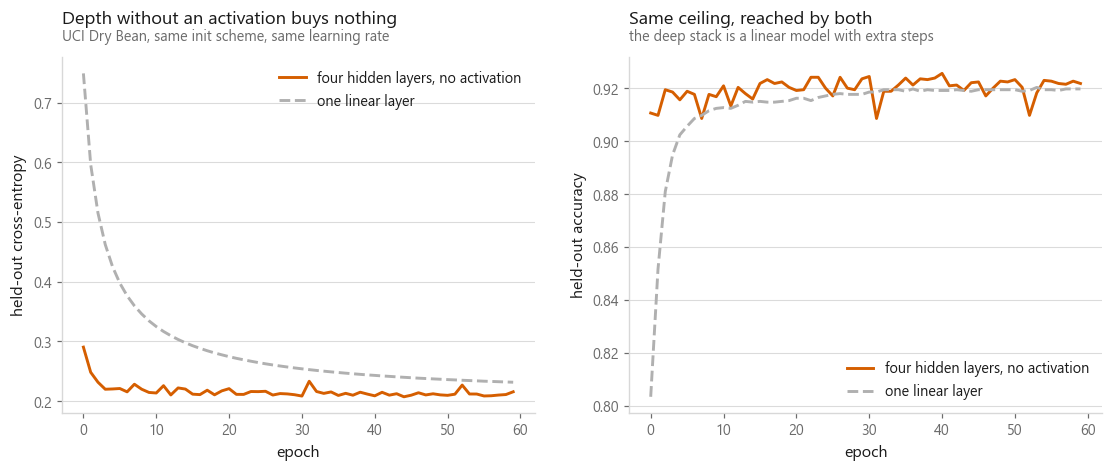

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.2))

axes[0].plot(history_deep["val_loss"], color=style.HIGHLIGHT, label="four hidden layers, no activation")
axes[0].plot(history_flat["val_loss"], color=style.NEUTRAL, linestyle="--", label="one linear layer")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("held-out cross-entropy")
axes[0].legend()
style.title(axes[0], "Depth without an activation buys nothing",
            "UCI Dry Bean, same init scheme, same learning rate")

axes[1].plot(history_deep["val_acc"], color=style.HIGHLIGHT, label="four hidden layers, no activation")
axes[1].plot(history_flat["val_acc"], color=style.NEUTRAL, linestyle="--", label="one linear layer")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("held-out accuracy")
axes[1].legend()
style.title(axes[1], "Same ceiling, reached by both",
            "the deep stack is a linear model with extra steps")

style.save(fig, FIG / "fig-01-linear-collapse.png")

The two curves take slightly different paths, because depth changes how
gradient descent moves even when it does not change what the model can express.
They land in the same place, and they have to: the trained deep stack *is* the
collapsed matrix printed above, to the last decimal float32 can hold.

## 2. The functions and their derivatives

Six functions do most of the work in practice.

| | definition | output range |
|---|---|---|
| **sigmoid** | $\sigma(x) = 1 / (1 + e^{-x})$ | between 0 and 1 |
| **tanh** | $\tanh(x)$ | between -1 and 1 |
| **ReLU** | $\max(0, x)$ | 0 and up |
| **LeakyReLU** | $x$ if $x > 0$, else $\alpha x$ for a small slope $\alpha$ | unbounded both ways |
| **ELU** | $x$ if $x > 0$, else $e^{x} - 1$ | above -1 |
| **GELU** | $x\,\Phi(x)$, where $\Phi$ is the normal CDF | slightly below 0 and up |

The function itself is the part everyone draws. The derivative is the part that
decides whether your network trains, because backpropagation multiplies one
derivative per layer. I get the derivatives from autograd rather than typing
them out, which is also a check that I typed the functions correctly.

In [7]:
ACTIVATIONS = {
    "sigmoid": nn.Sigmoid,
    "tanh": nn.Tanh,
    "ReLU": nn.ReLU,
    "LeakyReLU": nn.LeakyReLU,
    "ELU": nn.ELU,
    "GELU": nn.GELU,
}

GRID = torch.linspace(-6.0, 6.0, 601)
GRID_NP = GRID.numpy()
AT_ZERO = int(np.abs(GRID_NP).argmin())         # linspace lands on 0 only to float precision


def curve(activation):
    """Values and derivatives of an activation on the grid, both from autograd."""
    x = GRID.clone().requires_grad_(True)
    y = activation(x)
    y.sum().backward()                          # sum, so each x gets its own dy/dx
    return y.detach().numpy(), x.grad.numpy()


rows, drawn = [], {}
for name, act in ACTIVATIONS.items():
    values, slopes = curve(act())
    drawn[name] = (values, slopes)
    rows.append({
        "activation": name,
        "f(0)": values[AT_ZERO],
        "max |f'|": np.abs(slopes).max(),
        "flat share of grid": float((np.abs(slopes) < 0.01).mean()),
        "output min": values.min(),
        "output max": values.max(),
    })

print(f"LeakyReLU negative slope in PyTorch: {nn.LeakyReLU().negative_slope}")
print()
print(pd.DataFrame(rows).round(4).to_string(index=False))

LeakyReLU negative slope in PyTorch: 0.01

activation  f(0)  max |f'|  flat share of grid  output min  output max
   sigmoid   0.5    0.2500              0.2363      0.0025      0.9975
      tanh   0.0    1.0000              0.5025     -1.0000      1.0000
      ReLU   0.0    1.0000              0.5008      0.0000      6.0000
 LeakyReLU   0.0    1.0000              0.0000     -0.0600      6.0000
       ELU   0.0    1.0000              0.1165     -0.9975      6.0000
      GELU   0.0    1.1289              0.2479     -0.1700      6.0000


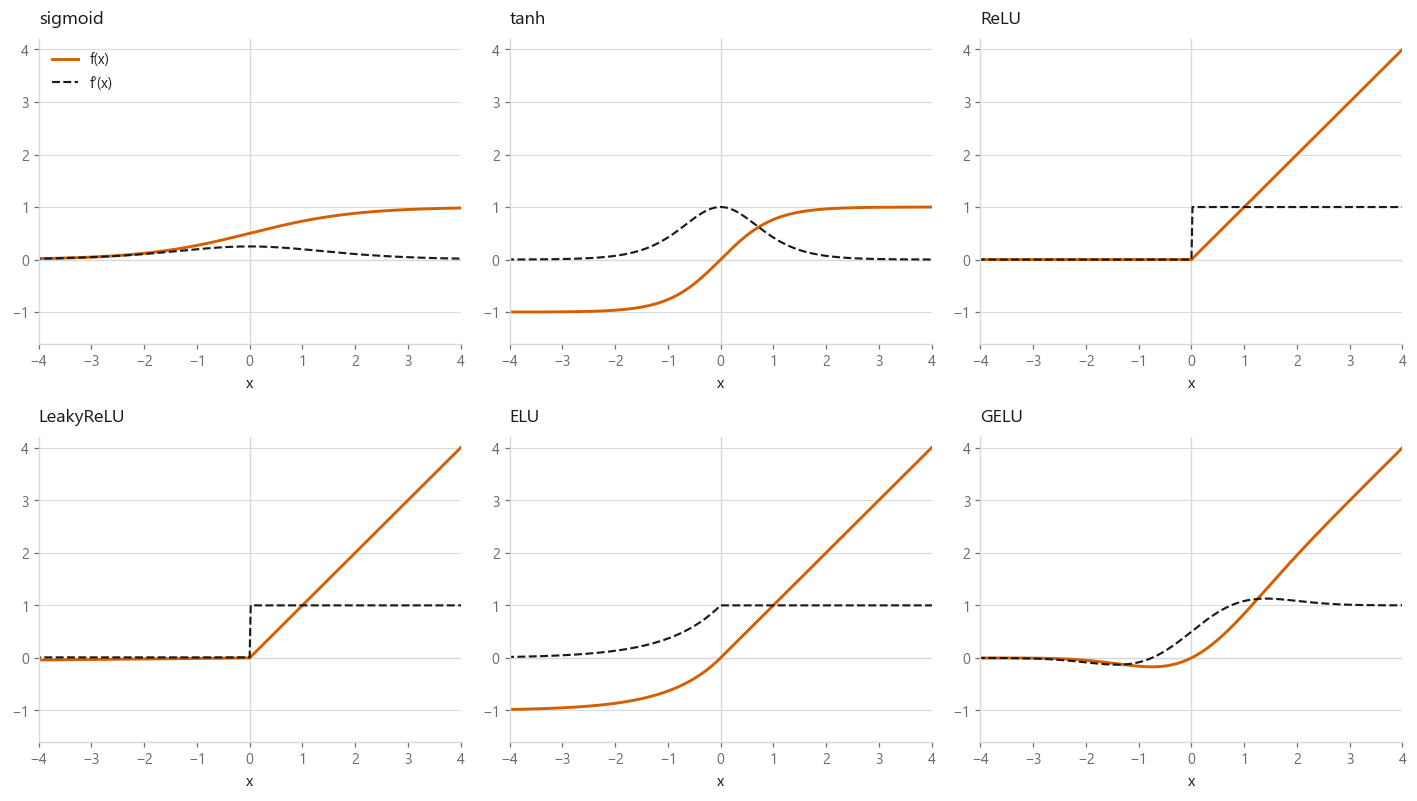

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(13.0, 7.4))

for ax, (name, (values, slopes)) in zip(axes.ravel(), drawn.items()):
    ax.axhline(0, color=style.RULE, linewidth=0.9)
    ax.axvline(0, color=style.RULE, linewidth=0.9)
    ax.plot(GRID_NP, values, color=style.HIGHLIGHT, label="f(x)")
    ax.plot(GRID_NP, slopes, color=style.INK, linestyle="--", linewidth=1.4, label="f'(x)")
    ax.set_xlim(-4.0, 4.0)                      # the grid runs wider; this is where the shape lives
    ax.set_ylim(-1.6, 4.2)
    ax.set_xlabel("x")
    style.title(ax, name)

axes[0, 0].legend(loc="upper left")
fig.tight_layout()
style.save(fig, FIG / "fig-02-activations.png")

Read the dashed lines and the table together, because that is where the rest of
the notebook comes from.

The sigmoid and tanh derivatives are bumps. They are near zero for most inputs
and their peak sits in the middle, and for the sigmoid that peak is well below
one, as the table prints. Multiply several such numbers together, one per
layer, and the product falls off a cliff. That is section 3.

ReLU's derivative is a step: exactly one on the right, exactly zero on the left.
No shrinking on the active side, which is why it trains deep networks that
sigmoid cannot. The flat left side is not saturation, it is an off switch, and
a unit stuck on the wrong side of it receives a gradient of exactly zero. That
is section 4.

LeakyReLU, ELU and GELU are all answers to the same question: keep the
non-shrinking right-hand side, and give the left-hand side a small non-zero
slope so a unit that switches off can find its way back.

## 3. Vanishing gradients, measured

Backpropagation multiplies, layer by layer. The gradient arriving at layer $k$
of an $L$-layer network carries a factor of $f'(z)$ for every layer between $k$
and the loss. Small numbers multiplied many times get very small, and there is
nothing subtle about the arithmetic.

Rather than argue about it, I take one batch, run one backward pass through a
deep and narrow network, and print the mean $|\partial L / \partial W|$ for each
layer. Deep and narrow is deliberate: depth is what drives this effect and width
only makes the run slower.

In [9]:
DEPTH, WIDTH = 8, 32
batch_X, batch_y = X_train_t[:512], y_train_t[:512]


def layer_gradients(model, X, y):
    """Mean |dL/dW| for every Linear layer, from a single backward pass."""
    model.zero_grad()
    nn.CrossEntropyLoss()(model(X), y).backward()
    return [m.weight.grad.abs().mean().item() for m in model if isinstance(m, nn.Linear)]


gradients = {"at initialisation": {}, "after five epochs": {}}
for name in ["sigmoid", "ReLU"]:
    net = build(DEPTH, WIDTH, ACTIVATIONS[name])
    gradients["at initialisation"][name] = layer_gradients(net, batch_X, batch_y)
    train(net, X_train_t, y_train_t, X_test_t, y_test_t, epochs=5, lr=0.1)
    gradients["after five epochs"][name] = layer_gradients(net, batch_X, batch_y)

table = pd.DataFrame({
    "layer": np.arange(1, DEPTH + 2),
    "sigmoid": gradients["at initialisation"]["sigmoid"],
    "ReLU": gradients["at initialisation"]["ReLU"],
})
table["ReLU / sigmoid"] = table["ReLU"] / table["sigmoid"]
print("mean |dL/dW| per layer at initialisation, layer 1 nearest the input\n")
print(table.to_string(index=False, float_format=lambda v: f"{v:,.3e}"))

for when, series in gradients.items():
    for name, values in series.items():
        print(f"\n{name}, {when}: last layer is "
              f"{values[-1] / values[0]:,.1f} times the first layer's gradient")

mean |dL/dW| per layer at initialisation, layer 1 nearest the input

 layer   sigmoid      ReLU  ReLU / sigmoid
     1 3.915e-09 1.759e-05       4.494e+03
     2 1.585e-08 1.404e-05       8.859e+02
     3 1.041e-07 1.518e-05       1.458e+02
     4 8.379e-07 1.085e-05       1.295e+01
     5 5.269e-06 1.053e-05       1.998e+00
     6 4.724e-05 2.950e-05       6.244e-01
     7 3.002e-04 6.586e-05       2.194e-01
     8 2.242e-03 2.754e-04       1.229e-01
     9 3.033e-02 1.301e-03       4.289e-02

sigmoid, at initialisation: last layer is 7,746,812.8 times the first layer's gradient

ReLU, at initialisation: last layer is 73.9 times the first layer's gradient

sigmoid, after five epochs: last layer is 1,351,474.6 times the first layer's gradient

ReLU, after five epochs: last layer is 16.2 times the first layer's gradient


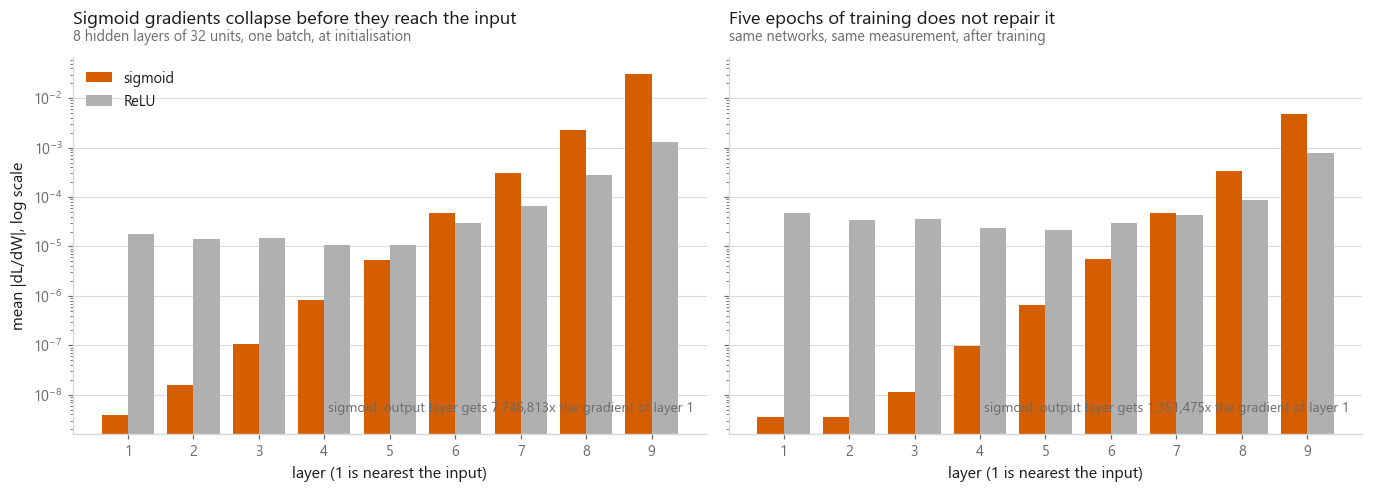

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.6), sharey=True)
idx = np.arange(DEPTH + 1)
bar_width = 0.4

for ax, (when, series) in zip(axes, gradients.items()):
    ax.bar(idx - bar_width / 2, series["sigmoid"], bar_width,
           color=style.HIGHLIGHT, label="sigmoid")
    ax.bar(idx + bar_width / 2, series["ReLU"], bar_width,
           color=style.NEUTRAL, label="ReLU")
    ax.set_yscale("log")
    ax.set_xticks(idx)
    ax.set_xticklabels([str(i + 1) for i in idx])
    ax.set_xlabel("layer (1 is nearest the input)")
    ax.annotate(f"sigmoid: output layer gets "
                f"{series['sigmoid'][-1] / series['sigmoid'][0]:,.0f}x the gradient of layer 1",
                xy=(0.98, 0.06), xycoords="axes fraction", ha="right",
                fontsize=9, color=style.MUTED)

axes[0].set_ylabel("mean |dL/dW|, log scale")
axes[0].legend()
style.title(axes[0], "Sigmoid gradients collapse before they reach the input",
            f"{DEPTH} hidden layers of {WIDTH} units, one batch, at initialisation")
style.title(axes[1], "Five epochs of training does not repair it",
            "same networks, same measurement, after training")

fig.tight_layout()
style.save(fig, FIG / "fig-03-vanishing-gradients.png")

The y-axis is logarithmic, so each gridline is a factor of ten. The sigmoid
bars fall by orders of magnitude on the way to the input while the ReLU bars
stay within a narrow band of each other. Compare the printed ratios rather than
eyeballing the bars.

The early layers of the sigmoid network are barely moving. They are the layers
that build the features every later layer depends on, and they are learning
hundreds or thousands of times slower than the output layer. The network is not
broken, it is untrainable in any reasonable amount of time, and from the outside
that looks like a model that simply refuses to fit.

This is the historical reason deep networks were considered impractical before
the late 2000s. The architecture was not the obstacle. The derivative of the
sigmoid was.

## 4. Dying ReLU, measured

ReLU has its own failure, and it comes from the same flat region that makes it
cheap. If a unit's pre-activation is negative for every row in the data, it
outputs zero for every row, and its gradient is exactly zero — not small,
zero. Gradient descent cannot move a weight whose gradient is zero, so the unit
stays off forever. It has died.

Here is the mechanism on a single unit, with nothing else going on.

In [11]:
for name, act in [("ReLU", nn.ReLU()), ("LeakyReLU", nn.LeakyReLU())]:
    w = torch.tensor([[2.0]], requires_grad=True)
    b = torch.tensor([-9.0], requires_grad=True)     # far enough negative to switch the unit off
    x = torch.tensor([[1.0], [2.0], [3.0]])          # every row leaves the unit off
    act(x @ w.T + b).sum().backward()
    print(f"{name:>10}: dL/dw = {w.grad.item():+.4f}, dL/db = {b.grad.item():+.4f}")

print("\nZero means the unit can never recover. A small number means it can.")

      ReLU: dL/dw = +0.0000, dL/db = +0.0000
 LeakyReLU: dL/dw = +0.0600, dL/db = +0.0300

Zero means the unit can never recover. A small number means it can.


Now the same thing inside a real network. I count the hidden units whose
pre-activation is at or below zero for every row of a batch, which is the
condition above, and track that count while training. Both networks start from
identical weights and get the same learning rate — a deliberately high one,
since an oversized learning rate is the usual way units get pushed off a cliff
they cannot climb back up.

In [12]:
def off_fraction(model, X):
    """Share of hidden units switched off for every row of X.

    Under ReLU these units emit zero and receive zero gradient. Under LeakyReLU
    the same units are off, but they still pass a small gradient, so the count
    means something different in each case — which is exactly the comparison.
    """
    off = total = 0
    modules = list(model)
    h = X
    with torch.no_grad():
        for i, m in enumerate(modules):
            h = m(h)
            if isinstance(m, nn.Linear) and i < len(modules) - 1:
                off += int((h.max(dim=0).values <= 0).sum())
                total += h.shape[1]
    return off / total


def zero_gradient_units(model, X, y):
    """Hidden units whose entire weight row has a gradient of exactly zero."""
    model.zero_grad()
    nn.CrossEntropyLoss()(model(X), y).backward()
    modules = list(model)
    return sum(int((m.weight.grad.abs().sum(dim=1) == 0).sum())
               for i, m in enumerate(modules)
               if isinstance(m, nn.Linear) and i < len(modules) - 1)


PROBE_X, PROBE_Y = X_train_t[:1024], y_train_t[:1024]


def probe(model):
    return off_fraction(model, PROBE_X)


DYING_DEPTH, DYING_WIDTH, DYING_LR = 4, 32, 1.5

dying = {}
for name in ["ReLU", "LeakyReLU"]:
    net = build(DYING_DEPTH, DYING_WIDTH, ACTIVATIONS[name])
    history = train(net, X_train_t, y_train_t, X_test_t, y_test_t,
                    epochs=30, lr=DYING_LR, probe=probe)
    history["probe"].insert(0, probe(build(DYING_DEPTH, DYING_WIDTH, ACTIVATIONS[name])))
    dying[name] = (net, history)                # index 0 is now the untrained network

for name, (net, history) in dying.items():
    print(f"{name:>10}: units off for the whole batch, untrained {history['probe'][0]:.4f}, "
          f"peak {max(history['probe']):.4f}, trained {history['probe'][-1]:.4f}"
          f"  |  exactly-zero gradients at the end: "
          f"{zero_gradient_units(net, PROBE_X, PROBE_Y)}"
          f"  |  held-out accuracy {history['val_acc'][-1]:.4f}")

      ReLU: units off for the whole batch, untrained 0.1250, peak 0.5859, trained 0.5703  |  exactly-zero gradients at the end: 128  |  held-out accuracy 0.2607
 LeakyReLU: units off for the whole batch, untrained 0.1250, peak 0.4688, trained 0.0000  |  exactly-zero gradients at the end: 0  |  held-out accuracy 0.0970


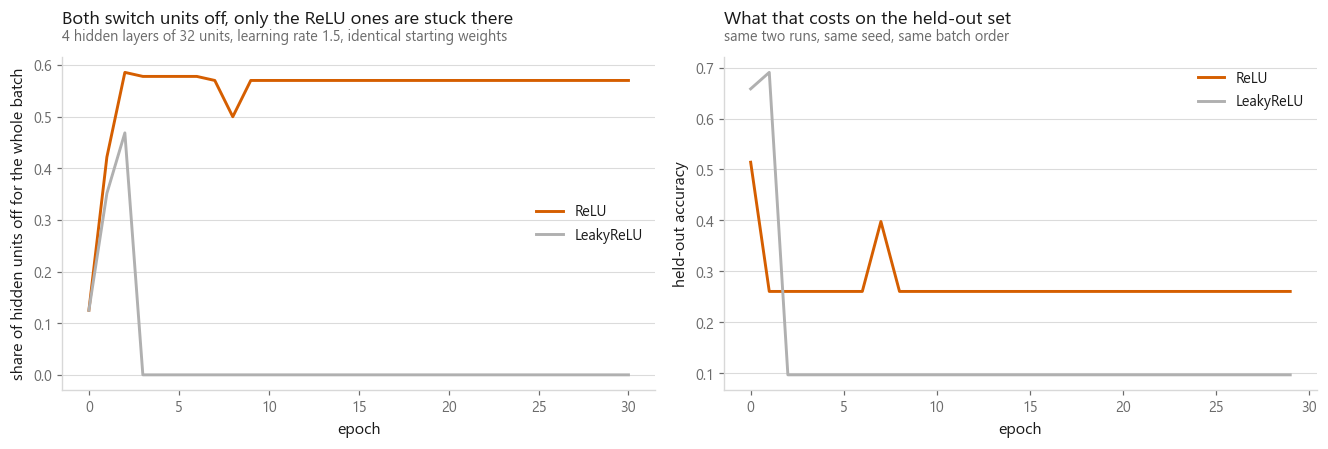

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.2))
colours = {"ReLU": style.HIGHLIGHT, "LeakyReLU": style.NEUTRAL}

for name, (net, history) in dying.items():
    axes[0].plot(history["probe"], color=colours[name], label=name)
    axes[1].plot(history["val_acc"], color=colours[name], label=name)

axes[0].set_xlabel("epoch"); axes[0].set_ylabel("share of hidden units off for the whole batch")
axes[0].legend()
style.title(axes[0], "Both switch units off, only the ReLU ones are stuck there",
            f"{DYING_DEPTH} hidden layers of {DYING_WIDTH} units, learning rate {DYING_LR}, "
            "identical starting weights")

axes[1].set_xlabel("epoch"); axes[1].set_ylabel("held-out accuracy")
axes[1].legend()
style.title(axes[1], "What that costs on the held-out set",
            "same two runs, same seed, same batch order")

fig.tight_layout()
style.save(fig, FIG / "fig-04-dead-units.png")

Two things to take from the printed line rather than the chart. The ReLU
network ends with units whose gradient is exactly zero, and the LeakyReLU
network ends with none, whatever its off-count looks like. Those zero-gradient
units are capacity you paid for and can never use again.

The fix is the small negative slope. A LeakyReLU unit that is off still passes a
little gradient, so a step in the right direction can bring it back. ELU and
GELU do the same job with a smooth curve instead of a kink.

In fairness to ReLU: a sensible learning rate makes this rare, and plenty of
production networks use plain ReLU without trouble. The reason to know about it
is diagnostic. When a network's accuracy stalls well below what the same shape
reached yesterday, counting dead units takes one function and often explains it.

## 5. Compared fairly

Same architecture, same starting weights, same learning rate, same number of
epochs, same batch order. Only the activation changes.

In [14]:
import time

FAIR_DEPTH, FAIR_WIDTH, FAIR_LR, FAIR_EPOCHS, TARGET = 4, 32, 0.2, 50, 0.85

comparison, curves = [], {}
for name, act in ACTIVATIONS.items():
    net = build(FAIR_DEPTH, FAIR_WIDTH, act)
    started = time.perf_counter()
    history = train(net, X_train_t, y_train_t, X_test_t, y_test_t,
                    epochs=FAIR_EPOCHS, lr=FAIR_LR)
    reached = next((e + 1 for e, a in enumerate(history["val_acc"]) if a >= TARGET),
                   float("nan"))
    curves[name] = history
    comparison.append({
        "activation": name,
        "held-out accuracy": history["val_acc"][-1],
        "held-out loss": history["val_loss"][-1],
        f"epochs to {TARGET}": reached,
        "seconds": time.perf_counter() - started,
    })

frame = pd.DataFrame(comparison).sort_values("held-out accuracy", ascending=False)
print(frame.round(4).to_string(index=False))

activation  held-out accuracy  held-out loss  epochs to 0.85  seconds
      GELU             0.9268         0.1883             2.0  17.2576
 LeakyReLU             0.9268         0.1907             2.0  15.8714
      ReLU             0.9259         0.1892             2.0  13.3171
      tanh             0.9236         0.1919             2.0  14.3709
       ELU             0.9227         0.1876             1.0  16.5162
   sigmoid             0.7546         0.7305             NaN  12.7537


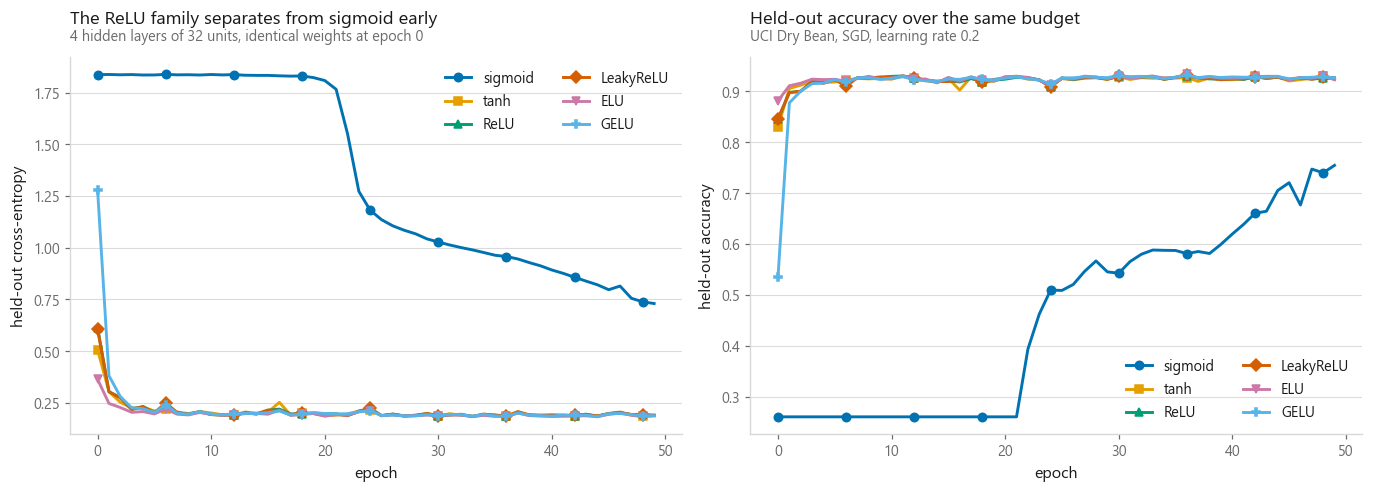

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.6))

for i, (name, history) in enumerate(curves.items()):
    axes[0].plot(history["val_loss"], color=style.PALETTE[i], marker=style.MARKERS[i],
                 markevery=6, label=name)
    axes[1].plot(history["val_acc"], color=style.PALETTE[i], marker=style.MARKERS[i],
                 markevery=6, label=name)

axes[0].set_xlabel("epoch"); axes[0].set_ylabel("held-out cross-entropy")
axes[0].legend(ncol=2)
style.title(axes[0], "The ReLU family separates from sigmoid early",
            f"{FAIR_DEPTH} hidden layers of {FAIR_WIDTH} units, identical weights at epoch 0")

axes[1].set_xlabel("epoch"); axes[1].set_ylabel("held-out accuracy")
axes[1].legend(ncol=2, loc="lower right")
style.title(axes[1], "Held-out accuracy over the same budget",
            f"UCI Dry Bean, SGD, learning rate {FAIR_LR}")

fig.tight_layout()
style.save(fig, FIG / "fig-05-comparison.png")

Read the table before the chart. On four hidden layers the sigmoid network is
last, and the table says by how much and how many epochs it costs. The
differences among ReLU, LeakyReLU, ELU and GELU are small here, which is the
honest result and matches what I have seen elsewhere: the large gain is going
from a saturating activation to a non-saturating one, and everything after that
is a refinement.

It would be a mistake to read the ordering of the top four as a ranking. Sixteen
tabular features and four narrow layers do not stress an activation the way a
fifty-layer vision network does. GELU won transformers on problems this
experiment cannot see.

## Cheat sheet

| | |
|---|---|
| **Default** | ReLU. Reach for something else when you have a reason, not by default |
| **Deep and stalling** | Suspect the activation before the architecture. Measure `weight.grad.abs().mean()` per layer |
| **Sigmoid and tanh** | Keep them for gates and bounded outputs. Not for hidden layers in a deep stack |
| **Dying ReLU** | Count units with `pre_activation.max(dim=0).values <= 0`. Fix with LeakyReLU, ELU or a smaller learning rate |
| **Output layer** | No activation before `CrossEntropyLoss`. Sigmoid for one binary output, nothing for regression |
| **Never** | An identity activation between layers. It is the same model as no hidden layers at all |

## What to remember

1. Without a non-linearity, any stack of linear layers multiplies out into one
   matrix. The collapsed matrix in section 1 reproduces the trained network
   exactly.
2. The derivative decides whether a network trains, because backpropagation
   multiplies one derivative per layer.
3. Sigmoid derivatives peak well below one, so the product across layers
   vanishes and the early layers stop learning. Measure it, do not guess.
4. ReLU's derivative is one on the active side, which is why depth became
   practical.
5. A ReLU unit that is off for all inputs receives a gradient of exactly zero
   and never recovers. A small negative slope leaves it a way back.
6. On easy tabular data every non-saturating activation lands in much the same
   place. Pick ReLU, and change it when a measurement tells you to.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [07-05 Optimisers: SGD, Momentum, RMSProp, Adam](../05-optimisers/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#DeepLearning` `#ActivationFunctions` `#ReLU` `#VanishingGradient` `#PyTorch`
`#NeuralNetwork` `#MachineLearning` `#Python` `#MLTutorial`
`#LearnMachineLearning` `#AI`